# Линейная регрессия


Линейные методы предполагают, что между признаками объекта и целевой переменной существует линейная зависимость, то есть:
$$ \widehat{y} = w_1 x_1 + w_2 x_2 + ... + w_k x_k + b,$$
где $\widehat{y}$ - целевая переменная (что мы хотим предсказать), $x_j$ - $j$-ый признак объекта $x$, $w_j$ - вес $i$-го признака, $b$ - bias (смещение, свободный член).

В задаче линейной регрессии $\widehat{y}$ - это действительное число.

Часто для упрощения записи вводят дополнительный фиктивный признак $x_0$, который всегда равен 1, тогда bias - вес этого признака. В этом случае формула может быть записана как скалярное произведение:
$$ \widehat{y} = <w, x> $$

В матричной форме формулу можно переписать следующим образом:
$$ \widehat{y} = Xw,$$
$\widehat{y}$ - вектор значений целевой переменной размера $n$, $X$ - матрица значений признаков объектов размера $n \times (k+1)$, $w$ - вектор весов размера $k+1$. То есть в наших данных имеется $n$ объектов, каждый их которых описан $k+1$ признаками (включая один фиктивный).



Формально в матричной форме модель задаётся следующим образом:
$$ y = Xw + \epsilon$$

На практике $\widehat{y}$ отличается от реальных значений, которые принимает целевая переменная $y$. Разницу между реальным значением и предсказанным, обозначим как $\epsilon$ - вектор значений случайной переменной, соответствующая случайной, непрогнозируемой ошибке модели. Отметим, что математическое ожидание по вектору случайных ошибок $\epsilon$ равно нулю.

Важно отметить, что параметрами этой модели являются веса $w$. Когда говорят об обучении какого-либо алгоритма машинного обучения, как правило, имеют в виду настройку весов, т.е. **параметров** модели.  

Загрузим необходимые библиотеки

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

Пример 1. Сгенерируем искусственные данные. Сначала поработаем с простейшим одномерным случаем, когда у нас значение $y$ будет зависеть только от одного значения $x$.




In [3]:
def generate_data(n_points=20):
  """
    Принимает на вход n_points точек
    Возвращает данные для обучения и теста
  """
  X = np.linspace(-5, 5, n_points)
  y = 10 * X - 7

  X_train = X[0::2].reshape(-1, 1)
  y_train = y[0::2] + np.random.randn(int(n_points/2)) * 10

  X_test = X[1::2].reshape(-1, 1)
  y_test = y[1::2] + np.random.randn(int(n_points/2)) * 10

  print(f'Generated {len(X_train)} train samples and {len(X_test)} test samples')
  return X, X_train, y_train, X_test, y_test

In [4]:
X, X_train, y_train, X_test, y_test = generate_data(100)

Generated 50 train samples and 50 test samples


Визуализируем данные, используя библиотеку matplotlib. Мы сразу разделили наши данные на обучающую и тестовую выборки (точки обозначены разными цветами).

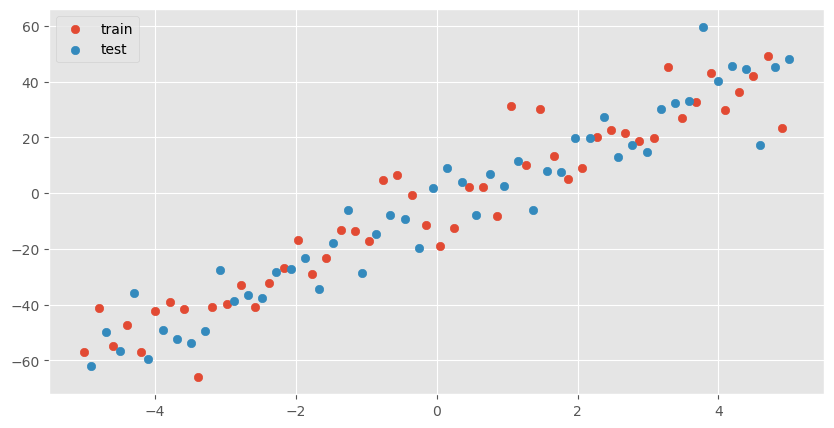

In [5]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.legend(loc='best')
plt.show()

Один из способов вычислить значения параметров модели, давно знаком. Этот метод минимизирует среднеквадратичную ошибку между реальным значением зависимой переменной и прогнозом, выданным моделью. Для минимизации мы производную (градиент) просто приравниваем к 0 и аналитически решаем уравнение. Аналитическое решение дает:
$$ w = (X^TX)^{-1}X^TY $$

В качестве задания нужно будет реализовать этот алгоритм настройки параметров модели. Какие у этого метода есть проблемы?

## Что такое мультиколлинеарность

**Мультиколлинеарность** возникает, когда признаки сильно связаны друг с другом. Если связь точная, матрица $X^TX$ становится вырожденной, и её нельзя обратить. Если связь почти точная, матрица формально может быть обратимой, но веса модели становятся нестабильными: небольшое изменение данных может сильно изменить коэффициенты.

Пример плохой ситуации:

$$x_3 = 2x_1 + 5x_2.$$

В этом случае признак $x_3$ не добавляет новой информации. На практике такие признаки лучше удалить, объединить или использовать регуляризацию.


In [2]:
# Пример: точная линейная зависимость признаков
X_bad = np.array([
    [1, 2, 4],
    [1, 3, 6],
    [1, 4, 8],
    [1, 5, 10]
], dtype=float)

# Третий столбец равен 2 * второму столбцу
XtX_bad = X_bad.T @ X_bad

print('Ранг X:', np.linalg.matrix_rank(X_bad))
print('Количество признаков:', X_bad.shape[1])
print('Определитель X^T X:', np.linalg.det(XtX_bad))

try:
    np.linalg.inv(XtX_bad)
except np.linalg.LinAlgError as error:
    print('Матрица необратима:', error)


Ранг X: 2
Количество признаков: 3
Определитель X^T X: 0.0
Матрица необратима: Singular matrix


А пока обучим нашу модель на тренировочной выборке и предскажем значения на тестовой выброке, воспользовавшись готовой реализацией из sklearn.
Предсказанные ответы сохраним в переменную `predictions`, а веса модели сохраним в переменные `w, b`.

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
model = LinearRegression()

model.fit(X_train, y_train) # обучение модели

w = model.coef_
b = model.intercept_

In [8]:
w, b

(array([10.24432403]), -5.026263959855361)

In [9]:
X[:5]

array([-5.       , -4.8989899, -4.7979798, -4.6969697, -4.5959596])

In [10]:
X.reshape(-1, 1)[:5]

array([[-5.       ],
       [-4.8989899],
       [-4.7979798],
       [-4.6969697],
       [-4.5959596]])

In [11]:
predictions = X_test.reshape(-1, 1).dot(w) + b

Визуализируем предсказания.

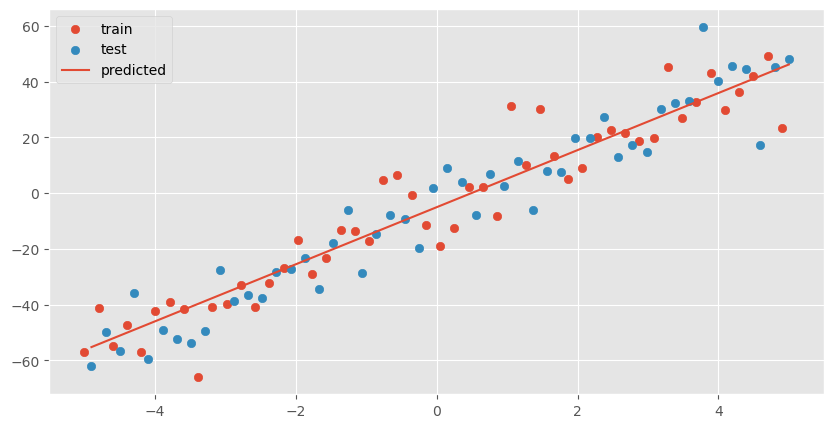

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(X_train, y_train, label='train')
plt.scatter(X_test, y_test, label='test')
plt.plot(X[1::2], predictions, label='predicted')
plt.legend(loc='best')
plt.show()

## Оценка результатов

Чтобы оценить качество работы алгоритма нам необходимо применяют разные метрики. Наиболее частые метрики средневадратичная и средняя абсолютная ошибки. Вычислим эти метрики на обучающей и на тестовой выборках.

 * *mean_absolute_error* - средняя абсолютная ошибка $|y_i - \widehat{y}_i|$
 * *mean_squared_error* - средняя квадратичная ошибка $(y_i - \widehat{y}_i)^2$

In [13]:
from sklearn.metrics import mean_squared_error

y_train_predicted = model.predict(X_train)
y_test_predicted = model.predict(X_test)

print('Train MSE: ', mean_squared_error(y_train, y_train_predicted))
print('Test MSE: ', mean_squared_error(y_test, y_test_predicted))

Train MSE:  133.31767137242926
Test MSE:  113.75938449099611


In [14]:
from sklearn.metrics import mean_absolute_error

print('Train MAE: ', mean_absolute_error(y_train, y_train_predicted))
print('Test MAE: ', mean_absolute_error(y_test, y_test_predicted))

Train MAE:  9.682607433526982
Test MAE:  8.37855219144171


# Оценка качества моделей

## Метрики качества

Запишем формулу для средней квадратичной ошибки:

$$MSE =  \frac{1}{\ell} \sum\limits_{i=1}^\ell (\widehat y^{(i)}  - y^{(i)})^2 $$

$\ell$ - количество объектов в обучающей выборке.

Для реальных задач чаще используют RMSE (квадратный корень из MSE), так как в MSE единицы измерения возводятся в квадрат. Например, когда мы предсказываем цену на квартиры в долларах, хотелось бы оценить в долларах (а не в квадратных долларах), на сколько мы ошибаемся.






In [13]:
# реализация MSE и MAE

def mse(true, pred):
    return np.mean((true - pred)**2)

def mae(true, pred):
    return np.mean(np.abs(true - pred))

(0.0, 40.0)

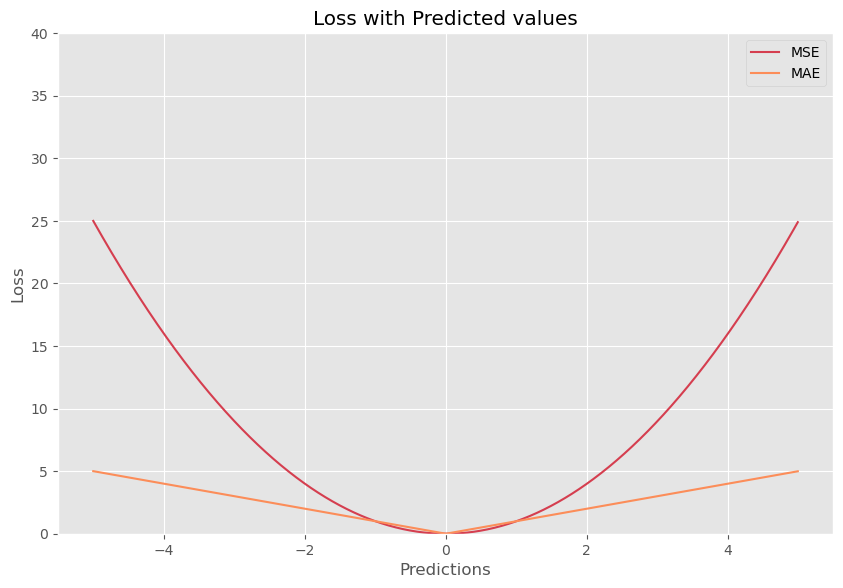

In [14]:
fig, ax1 = plt.subplots(1,1, figsize = (10,6.5))

target = np.repeat(0, 1000)
pred = np.arange(-5,5, 0.01)

# calculating loss function for all predictions.
loss_mse = [mse(target[i], pred[i]) for i in range(len(pred))]
loss_mae = [mae(target[i], pred[i]) for i in range(len(pred))]

losses = [loss_mse, loss_mae]
names = ['MSE', 'MAE']
cmap = ['#d53e4f',
'#fc8d59']

for lo in range(len(losses)):
    ax1.plot(pred, losses[lo], label = names[lo], color= cmap[lo])
ax1.set_xlabel('Predictions')
ax1.set_ylabel('Loss')
ax1.set_title("Loss with Predicted values")
ax1.legend()
ax1.set_ylim(bottom=0, top=40)

**Вопросы на обсуждение.**

Метрики качества и функция потерь.

Какие достоинства и недостатки есть у MSE и MAE?

*Дополнение:* Также используют метрику $R^2$ - коэффициент детерминации (он показывает отношение MSE к дисперсии). Фактически это нормированная среднеквадратичная ошибка. Если $R^2$ близка к единице, это значит, что модель хорошо обясняет данные.

Чтобы справиться с недостатками MSE и MAE используют метрику со сглаживанием (Huber loss, функция потерь Хубера)


$$
L_\delta(y, \widehat y) = \begin{cases}
 \frac{1}{2}(y - \widehat y)^2                   & \text{для } |y - \widehat y| \le \delta, \\
 \delta\, |y - \widehat y| - \frac{1}{2}\delta^2 & \text{иначе.}
\end{cases}
$$


Очевидно, что дельту тут нужно как-то подбирать.

In [17]:
def sm_mae(true, pred, delta):
    loss = np.where(np.abs(true-pred) < delta , 0.5*((true-pred)**2), delta*np.abs(true - pred) - 0.5*(delta**2))
    return np.mean(loss)

Также можно воспользоваться метрикой гиперболический косинус (ch, cosh).

$$L (y, \widehat y) =  \frac{1}{\ell} \sum\limits_{i=1}^\ell \log \cosh (\widehat y^{(i)}  - y^{(i)}) $$

In [18]:
def logcosh(true, pred):
    loss = np.log(np.cosh(pred - true))
    return np.mean(loss)

(0.0, 40.0)

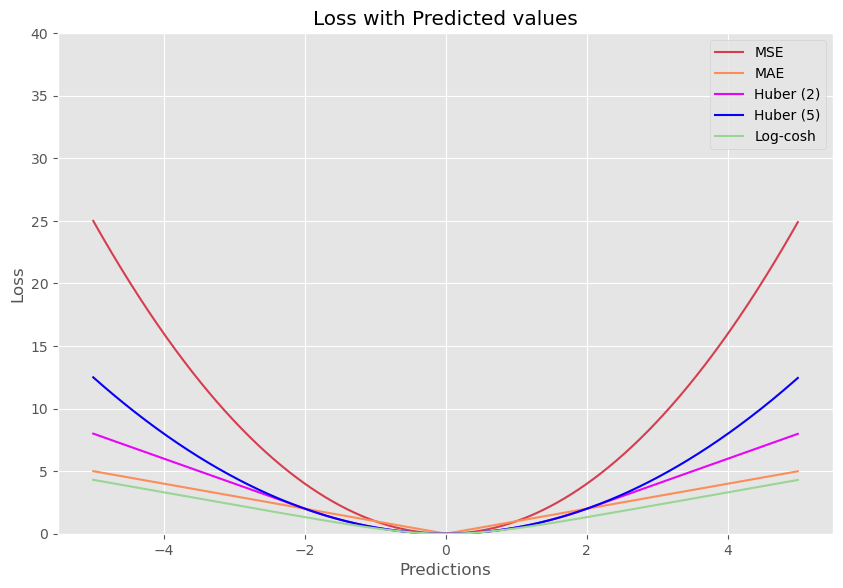

In [19]:
fig, ax1 = plt.subplots(1,1, figsize = (10,6.5))

target = np.repeat(0, 1000)
pred = np.arange(-5,5, 0.01)

# calculating loss function for all predictions.
loss_mse = [mse(target[i], pred[i]) for i in range(len(pred))]
loss_mae = [mae(target[i], pred[i]) for i in range(len(pred))]
loss_sm_mae1 = [sm_mae(target[i], pred[i], 2) for i in range(len(pred))]
loss_sm_mae2 = [sm_mae(target[i], pred[i], 5) for i in range(len(pred))]
loss_logcosh = [logcosh(target[i], pred[i]) for i in range(len(pred))]

losses = [loss_mse, loss_mae, loss_sm_mae1, loss_sm_mae2, loss_logcosh]
names = ['MSE', 'MAE','Huber (2)', 'Huber (5)', 'Log-cosh']
cmap = ['#d53e4f',
'#fc8d59',
'#e605f8',
'#0600f8',
'#99d594']

for lo in range(len(losses)):
    ax1.plot(pred, losses[lo], label = names[lo], color= cmap[lo])
ax1.set_xlabel('Predictions')
ax1.set_ylabel('Loss')
ax1.set_title("Loss with Predicted values")
ax1.legend()
ax1.set_ylim(bottom=0, top=40)

Ещё один распространнённый вид ошибки средняя абсолютная процентная ошибка MAPE (и его модификация SMAPE). Это относительные ошибки, то есть у них нет единицы измерения.

$$MAPE =  \frac{1}{\ell} \sum\limits_{i=1}^\ell |\widehat y^{(i)}  - y^{(i)}|/ y^{(i)}$$

В MAPE мы фактически соотносим разницу ошибки к правильному ответу (тем самым нормируем).

$$SMAPE =  \frac{1}{\ell} \sum\limits_{i=1}^\ell \frac{|\widehat y^{(i)}  - y^{(i)}|} {(|\widehat y^{(i)}| + |y^{(i)}|)/2}$$

SMAPE учитывает при нормировке и прогноз и правильный ответ.

## Кросс-валидация

Разделение набора данных на обучающую (train) и контрольную (test) - это стандартный подход для проверки **обобщающей способности алгоритма**. Этот подход называется подход с *отложенной выборкой*. При таком подходе мы обучаемся на одной выборке, а оцениваем качество на другой. Такой подход может привести к проблеме: наш результат будет зависеть от конкретного разбиения данных на обучающую и контролирующие выборки.

Решается эта проблема с помощью **кросс-валидации**. Самый распространённый подход заключается в следующем: размеченные данные разбиваем на $k$ блоков (прошу прощения за путаницу, ранее у нас $k$ было количеством признаков, теперь мы эту же букву используем для другого, просто такой тип кросс-валидации по английски называется k-fold). Эти блоки имеют примерно одинаковый размер (наиболее распространённое количество блоков от 5 до 10). Обучаются k алгоритмов, при этом они обучаются на всех блоках, кроме одного. После каждая алгоритм оценивается на том блоке, который не участвовал в обучении. Оценка усредняется.



Пример 2. Не всегда в задаче регрессии в качестве решения выступает прямая, как в предыдущем случае. Рассмотрим ещё один пример, в котором у объектов всё ещё один признак. Но теперь мы будм брать случайную точку на синусоиде и добавлять к ней шум — таким образом получим целевую переменную, признаком в этом случае будет координата $x$.

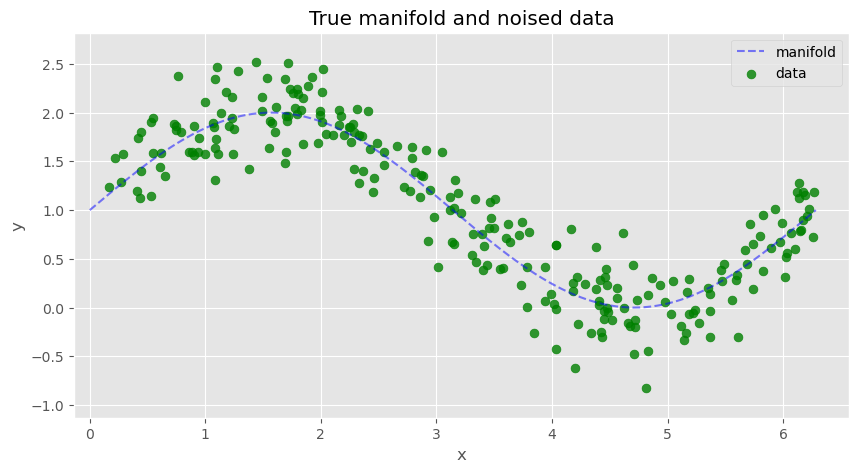

In [20]:
def generate_wave_set(n_support=1000, n_train=25, std=0.3):
    data = {}
    # выберем некоторое количество точек из промежутка от 0 до 2*pi
    data['support'] = np.linspace(0, 2*np.pi, num=n_support)
    # для каждой посчитаем значение sin(x) + 1
    # это будет ground truth
    data['values'] = np.sin(data['support']) + 1
    # из support посемплируем некоторое количество точек с возвратом, это будут признаки
    data['x_train'] = np.sort(np.random.choice(data['support'], size=n_train, replace=True))
    # опять посчитаем sin(x) + 1 и добавим шум, получим целевую переменную
    data['y_train'] = np.sin(data['x_train']) + 1 + np.random.normal(0, std, size=data['x_train'].shape[0])
    return data

data = generate_wave_set(1000, 250)

plt.figure(figsize=(10, 5))
margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')
plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right')
plt.title('True manifold and noised data')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [21]:
model = LinearRegression()

model.fit(data['x_train'].reshape(-1, 1), data['y_train']) # обучение модели

w = model.coef_
b = model.intercept_

In [22]:
w, b

(array([-0.34642611]), 2.1582101792827104)

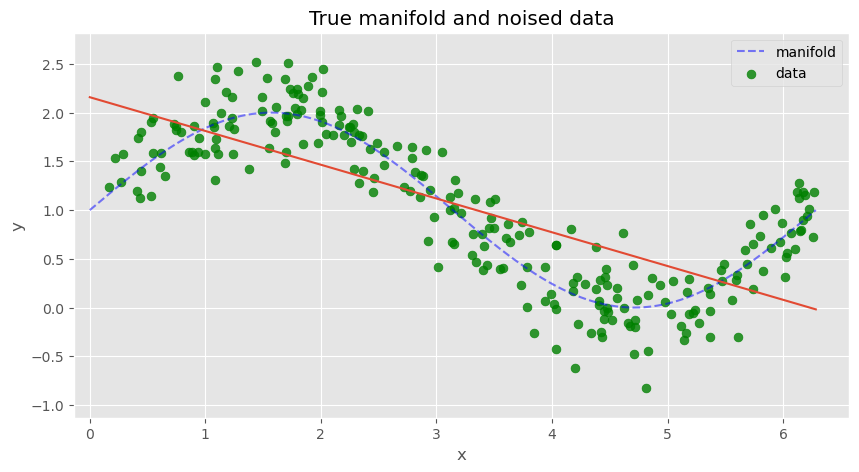

In [23]:
plt.figure(figsize=(10, 5))
margin = 0.3
plt.plot(data['support'], data['values'], 'b--', alpha=0.5, label='manifold')
plt.scatter(data['x_train'], data['y_train'], 40, 'g', 'o', alpha=0.8, label='data')
plt.xlim(data['x_train'].min() - margin, data['x_train'].max() + margin)
plt.ylim(data['y_train'].min() - margin, data['y_train'].max() + margin)
plt.legend(loc='upper right')
plt.title('True manifold and noised data')
plt.xlabel('x')
plt.ylabel('y')
plt.plot(data['support'], data['support'].reshape(-1, 1).dot(w) + b, label='predicted')
plt.show()

In [24]:
data['y_train'].shape

(250,)

In [25]:
y_train_predicted = model.predict(data['x_train'].reshape(-1, 1))
y_train_predicted.shape

(250,)

In [26]:
print('Train MSE: ', mean_squared_error(data['y_train'], y_train_predicted))

Train MSE:  0.282366264842616


Кажется, что-то пошло не так. Или всё нормально?

In [29]:
print('Train RMSE: ', np.sqrt(mean_squared_error(data['y_train'], y_train_predicted)))

Train RMSE:  0.5313814682905454


# Полиномиальная регрессия

Конечно, такое решение нас вряд ли может устроить. Нужно применить полинимиальную регрессию. Идея здесь такая. Каждый признак в исходную формулу может входить не только в первой степени, но и во второй, в третьей и так далее. То есть для случая, когда у нас только один признак:
$$ \widehat{y} = w_1 x_1 + w_2 x_1^2 + ... + w_k x_1^p + b,$$

In [32]:
from sklearn.preprocessing import PolynomialFeatures

Нужно будет самостоятельно разобраться с подбором правильно степени полинома. Это связано с проблемой undeffitting/overfitting

## Пример

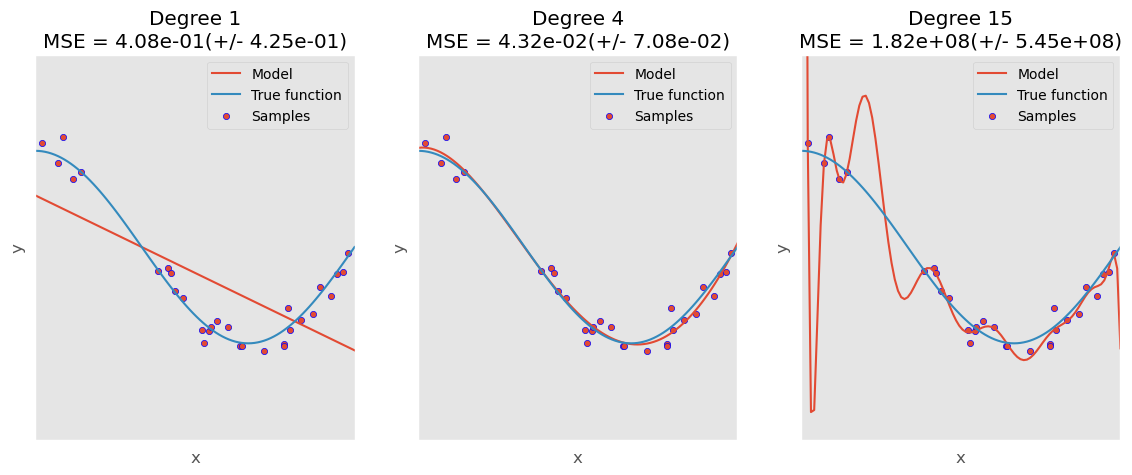

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
    return np.cos(1.5 * np.pi * X)

np.random.seed(0)

n_samples = 30
degrees = [1, 4, 15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1

plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())

    polynomial_features = PolynomialFeatures(degree=degrees[i],
                                             include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X[:, np.newaxis], y)

    # Evaluate the models using crossvalidation
    scores = cross_val_score(pipeline, X[:, np.newaxis], y,
                             scoring="neg_mean_squared_error", cv=10)

    X_test = np.linspace(0, 1, 100)
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    plt.plot(X_test, true_fun(X_test), label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.xlim((0, 1))
    plt.ylim((-2, 2))
    plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(
        degrees[i], -scores.mean(), scores.std()))
plt.show()

# Предобработка признаков

Применяя линейную модель мы предполагаем, что каждый признак линейно влияет на значение целевой переменной. Такое предположение редко оказывается верным, поэтому нужно либо применять другую модель (то есть искать алгоритм в другом семействе алгоритмов), либо для улучшения качества модели необходимо специальным образом предобрабатывать признаки. Рассмотрим некоторые подходы для предобработки признаков (кстати, эти подходы могут улучшить и метрическую модель kNN).

Введём обозначения: $f$ - признак, $j$ - номер признака. Тогда $f_j (x)$ - это $j$-ый признак объекта.  





## Категориальный признак

Довольно частая ситуация, когда один из признаков принимает значения из некоего конечного множества.

Примеры:
* в датасете sp500 у каждой компании указывался сектор: Industrials, Health Care, Information Technology, Financials и т.д.


Если $f_j (x)$ принимает значения из множества $C = \lbrace c_1, c_2, ..., c_m \rbrace$, то его можно заменить на $m$ новых бинарных признаков, принимающих значения 1 для соответствующего значения и 0 для остальных. Такой подход называется **one-hot encoding**.

Самый быстрый способ реализации - `get_dummies` из библиотеки `pandas`.

Существует также реализация `sklearn.preprocessing.OneHotEncoder`


## Нелинейная зависимость переменной от признака

Довольно зависимость целевой переменной от значения признака является нелинейной. Для того, чтобы такой признак мог быть корректно использован в линейной модели, нам необходимо **бинаризовать признак**.

Бинаризация делается в два шага. На первом шаге определяем минимальное и максимальное значение признака. И разбиваем весь этот интервал на $m$ интервалов (чаще всего одинакового размера, но можно и похитрее). На втором шаге смотрим в какой интервал попадает значение и создаём $m$ новых бинарных признаков.

## Масштабирование признаков

Масштабирование - это приведение признаков к единой шкале. Два самых частых способа масштабирования: стандартизация и нормализация на отрезок.


Стандартизация:

$$ x_{ij} = \frac{x_{ij}-\mu_j}{\sigma_j}  $$

Где $\mu_j$ - среднее арифметическое по признаку $j$, а $\sigma_j$ - дисперсия по нему же.

Нормализация в отрезок [0,1]:

$$ x_{ij} = \frac{x_{ij}-min (x_j)}{max(x_j)-min(x_j)}  $$

# Настройка параметров модели

Ранее занятии упоминали способ вычислить значения параметров модели методом наименьших квадратов. Параметры эти могут быть найдены аналитически. Это решение наглядное, точное и короткое.
$$ w = (X^TX)^{-1}X^TY $$

Вот это  $(X^TX)^{-1}X^T$ называют псевдообратная матрица. Проблема метода заключается в том, что вычисление псевдообратной матрицы очень затратно, также аналитического решения может не оказаться вовсе. В связи с этим при настройке параметров модели сначала находят функционал качества (функция потерь), а затем ищут минимум функционал качества численными методами.

## Эмпирический риск



Напомню про **минимизацию эмпирического риска**. Для задачи обучения по прецедентам вводится функция потерь: $L(\widehat{y}, y)$, характеризующая величину отклонения ответа (прогноза, predict) модели $\widehat{y} = a(x)$ от правильного ответа $y$ на одном произвольном объекте $x \in X$, где $a$ - это алгоритм, а $X$ - это множество объектов, имеющих признаковое описание, для которых известно значение целевой переменной. Пусть $\ell $ - это количество таких объектов.

Эмпирический риск $Q$ - это функционал (то есть функция от функции) качества, характеризующий среднюю ошибку алгоритма на выборке:
$$ Q (a,X) = \frac{1}{\ell} \sum\limits_{i=1}^\ell L(\widehat{y}, y) $$

Метод минимизация эмпирического риска заключается в том, чтобы в выбранном семействе алгоритмов найти такой алгоритм, который даст минимальное значение функционалу эмпирического риска.

Таким образом, если мы выбираем в качестве семейства моделей линейный модели, а в качестве задачи - задачу регрессии, то это позволит нам подобрать наиболее подходящую функцию потерь $L(\widehat{y}, y)$.

$$L(\widehat{y}, y) = (\widehat{y} - y)^2 $$

Обозначим $\widehat{y}^{(i)}$ и $y^{(i)}$ соответственно прогноз и правильный ответ на  i-ом объекте $x^{(i)}$. Заметим, что $ \widehat{y}^{(i)} = \sum\limits_{j=0}^k w_j x_j^{(i)} $. Тогда,

$$L(\widehat{y}, y) = (\sum\limits_{j=0}^k w_j x_j^{(i)}  - y^{(i)})^2 $$

$$ Q (a,X) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\sum\limits_{j=0}^k w_j x_j^{(i)}  - y^{(i)})^2 $$

$j$ - номер признака, $k$ - количество признаков.

Итак, эта функция зависит от $\widehat{y}$ и $y$, но на $y$ мы повлиять никак не можем. Когда мы будем искать минимум от эмпирического риска, мы можем повлиять только на $\widehat{y}$.

При этом на $x \in X $ мы хоть и можем как-то повлиять, но мы сейчас рассматриваем тот момент, когда признаковое описание объектов уже сформировано. И тогда единственно, от чего будет реально зависеть функция потерь в момент нахождения минимума эмпирического риска, это $w$, то есть веса в модели.

$$ Q (w) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\sum\limits_{j=0}^k w_j x_j^{(i)}  - y^{(i)})^2 $$


## Градиентный спуск

Давайте попробуем реализовать алгоритм настройки параметров модели через производные.

Рассмотрим функцию $k+1$ переменных:
$Q(w) = Q(w_0, w_1, \dots, w_k)$.

Производная функции нескольких переменных по одной переменной называется **частной производной**.  **Градиент функции многих переменных** $\nabla Q(w)$ - это вектор частных производных функции.

Производные функции от многих переменных можно определять, считая все аргументы, кроме того, по которому берем производную, константами.

Известно, что градиент является направление наискорейшего роста функции, а антиградиент направлением наискорейшего убывания.

$$ \nabla Q(w) = (\frac{\delta Q(w_0)}{\delta w_0}, \frac{\delta Q(w_1)}{\delta w_1}, \dots, \frac{\delta Q(w_k)}{\delta w_k} )$$

Идея алгоритма такая:
1. Инициализируем вектор весов случайными значениями (в случае в линейными моделями обычно не очень важно, как мы это делаем)
2. Фиксируем шаг обучения $\eta$ (например, $\eta = 0.001$). Шаг обучения - это гиперпараметр, мы его не обучаем, а подбираем.
3. Вычисляем градиент $\frac{\delta Q(w)}{\delta w}$
4. Для каждого измерения $j$ изменяем $w_j$  по следующему правилу: $ w_j = w_j - \eta \frac{\delta Q(w_j)}{\delta w_j}$
5. Повторяем шаг 4, пока не пройдет определенное количество шагов и/или мы не станем достаточно близко к точке минимума и/или значение $w_j$ перестанет изменяться.

Этот алгоритм называется **алгоритм градиентного спуска**. "Градиентного" -- потому что мы "спускаемся" к точке минимума, вычисляя производную (градиент) функции на каждом шаге.

Рассмотрим для случая с одним признаком.

$$ \triangledown Q(w) = \Big( \frac{\delta Q(w_0)}{\delta w_0}, \frac{\delta Q(w_1)}{\delta w_1} \Big)$$


$$ \frac{ \delta Q(w_0)}{\delta w_0} = 2\sum\limits_{i=0}^\ell (w_0 + w_1x_1^{(i)}  - y^{(i)})x_0 = 2\sum\limits_{i=0}^\ell (w_0 + w_1x_1^{(i)}  - y^{(i)}) $$

$$ \frac{ \delta Q(w_1)}{\delta w_1} = 2\sum\limits_{i=0}^\ell (w_0 + w_1x_1^{(i)}  - y^{(i)})x_1 $$

Для поиска минимума константы перед суммой вообще никакой роли не играют, их можно не учитывать.

$$ w_0^{(k+1)} = w_0^{(k)} - 2\eta \sum\limits_{i=0}^\ell (w_0^{(k)} + w_1^{(k)}x_1^{(i)}  - y^{(i)}) $$

$$ w_1^{(k+1)} = w_1^{(k)} - 2\eta \sum\limits_{i=0}^\ell (w_0^{(k)} + w_1^{(k)}x_1^{(i)}  - y^{(i)})x_1 $$

Эти изменения нужно делать итерационно. $k$ - это номер итерации.

Условия остановки:
1. веса перестали меняться ($ ||w^{(k+1)} = w^{(k)} || < \epsilon $)
2. близость градиента к 0 ($ ||\triangledown Q(w^{(k)})|| < \epsilon $)
3. ошибка на test перестала убывать



Выше было предложено фиксировать шаг обучения $\eta$ (например, $\eta = 0.001$). Шаг (коэффициент, темп) обучения $\eta$  влияет на величину изменения веса на каждой эпохе.  Чем меньше шаг, тем выше точность, но тем больше итераций требуется для спуска в минимум. Но если сделать шаг слишком большим, то можно "перескочить" минимум, алгоритм может не сойтись.

Однако, этот шаг может быть задан не константой. Иногда $\eta$ монотонно уменьшают по простой формуле.

$$\eta (k) = \frac{1}{k} $$

Иногда по сложной:

$$\eta (k) = \lambda \Big( \frac{s_0}{s_0+k} \Big)^p $$

В этой формуле обычно задают $s_0=1$, $p = 0.5$, $\lambda$ - гиперпараметр, который подбирают.

Обычно требуют, чтобы выполнялось условие:

$$\sum\limits_{k=1}^\infty \eta (k) = \infty$$
$$\sum\limits_{k=1}^\infty \big( \eta (k) \big)^2 < \infty$$

## Модификации градиентного спуска

Пусть $q_i(w)$ - это отдельные функции, соответствующие ошибкам на отдельных объектах. Тогда:

$$ Q (w) = \frac{1}{\ell} \sum\limits_{i=1}^\ell q_i(w) $$

и соответственно:

$$ \triangledown Q (w) = \frac{1}{\ell} \sum\limits_{i=1}^\ell \triangledown q_i(w)$$

Такой стандартный подход иначе называется полный градиент или «пакетный» («batch»). При этом подходе для корректировки параметров модели на каждой итерации используется градиент, который считается как сумма градиентов, вызванных **каждым** элементом обучения. То есть стандартному градиентному спуску требуется проход по всем обучающим данным для того, чтобы изменить параметры на одной итерации.

На больших наборах данных, это может быть не слишком эффективно. Поэтому существуют две модификации:

* mini-batch градиентный спуск (на каждой итерации используем не все, а только небольшую часть объектов)
* cтохастический градиентный спуск (на каждой итерации используем ровно один случайный объект).



То есть фактически ивместо полного градиента используется его оценка. Для стохастического градиентного спуска градиент суммы оценивается градиентов одного случайного объекта:

$$ \triangledown Q (w) \approx \triangledown q_{i_k}(w) $$

И тогда:
$$ w^{(k+1)} = w^{(k)} - \eta(k) \triangledown q_{i_k} \big( w^{(k)} \big)$$

В стохастическом градиентном спуске (SGD) особенно важно использовать $\eta(k)$, убывающую по мере увеличения $k$. У стандартного градиентного спуска есть свойство: при приближении к минимуму градиент уменьшается, за счёт чего происходит замедление процесса и попадание в окрестность минимума. В SGD этого свойства нет, метод может отдаляться от минимума, даже оказавшись рядом с ним.

Для метода mini-batch GD точность оценки повышают, за счёт использования $n$  слагаемых вместо одного ($n << \ell$). $n$ - размер пачки (батча).

$$ \triangledown Q (w) \approx \frac{1}{n} \sum\limits_{j=1}^n \triangledown q_{i_{kj}}(w) $$

$i_{kj}$ - случайно выбранные номера слагаемых.


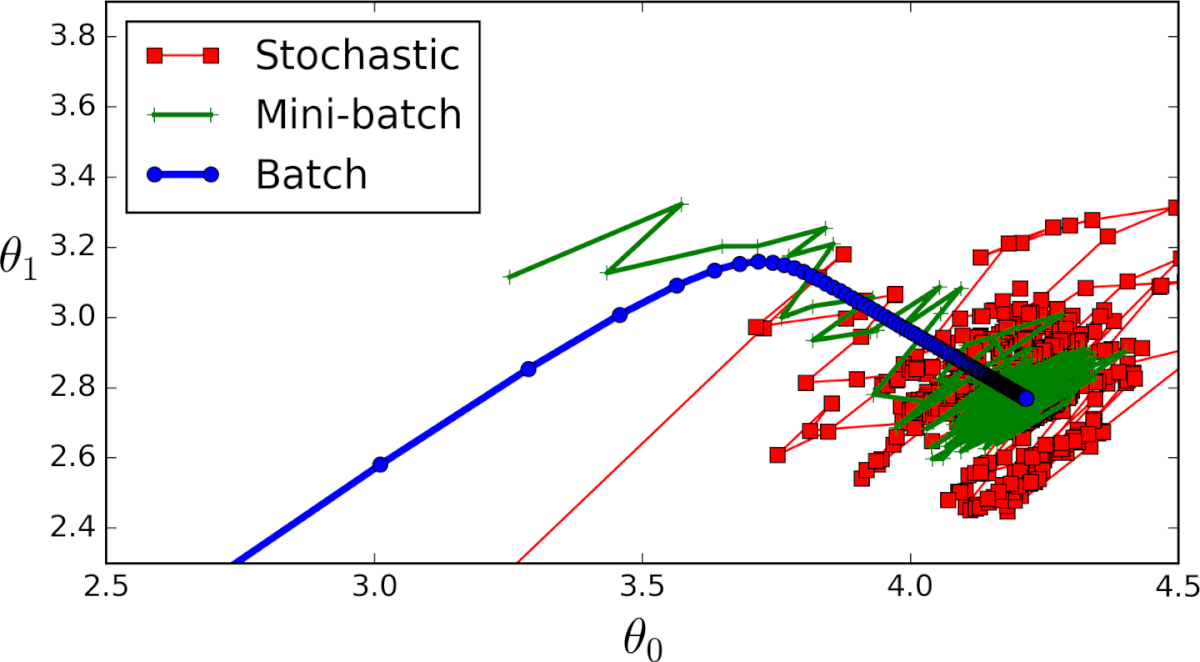

Существуют также и другие модификации градиентного метода: метод инерции (моментум), AdaGrad, RMSProp, Adam.

# Регуляризация

Минимизация эмпирического риска - это универсальный  универсальный подход, позволяющий сводить задачу обучения к задачам численной оптимизации. Поэтому его используют повсеместно.

Основной недостаток этого подхода **эффект переобучения (overfitting)**, который возникает практически всегда при использовании метода минимизации эмпирического риска.

Основные способы борьбы с переобучением: ограничение сложности модели, в том числе отбор признаков, и наложение дополнительных ограничений на параметры модели, в том числе **регуляризация**.

Регуляризация - это подход для борьбы с переобучением, который заключается в изменении функционала качества путём добавления нового слагаемого, позволяющего учитывать величину весов. Рассмотрим несколько наиболее распространённых способов регуляризации.

Напомню функционал без штрафов за веса:
$$ Q (w) = \frac{1}{\ell} \sum\limits_{i=1}^\ell (\sum\limits_{j=0}^k w_j x_j^{(i)}  - y^{(i)})^2 $$



Добавим к этому ещё одно слагаемое $R(w)$

$$ Q (w) = \frac{1}{\ell} \sum_{i=1}^\ell (\sum_{j=0}^k w_j x_j^{(i)}  - y^{(i)})^2 + \alpha R(w)$$

$\alpha \geq  0$ - это гиперпараметр, определяющий степень влияния нового слагаемого.
Фактически же разные способы (виды) регуляризации задаются только различными видами $R(w)$

### L2-регуляризация — Ridge

При L2-регуляризации к функции потерь добавляется сумма квадратов весов:

$$ Loss = MSE + \lambda \sum_{j=1}^{d} w_j^2

### L1-регуляризация — Lasso

При L1-регуляризации добавляется сумма модулей весов:

$$ Loss = MSE + \lambda \sum_{j=1}^{d} |w_j|

![image.png](https://proproprogs.ru/htm/ml/files/ml-l1-regulyarizator-otlichiya-mezhdu-l1-i-l2-regulyarizatorami.files/image023.jpg)


Также существует способ ElasticNet, объединяющий в себе две перечисленные выше регуляризации
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html#sklearn.linear_model.ElasticNet

Фактически добаляются два новых слагаемых, а не одно.

# Линейные модели для классификации

В задачах регрессии линейная модель предсказывает число. В задачах классификации нужно предсказать **класс** объекта: например, письмо является спамом или не спамом, клиент уйдёт или останется, опухоль доброкачественная или злокачественная.

Идея линейной классификации похожа на линейную регрессию: модель строит линейную комбинацию признаков

$$ z = w_1x_1 + w_2x_2 + \ldots + w_kx_k + b = \langle w, x \rangle + b.$$

Но теперь значение $z$ не является итоговым численным прогнозом. Оно используется для выбора класса.

Для бинарной классификации часто используют правило:

$$ \widehat{y} =
\begin{cases}
1, & \text{если } \langle w, x \rangle + b \geq 0,\\
0, & \text{если } \langle w, x \rangle + b < 0.
\end{cases}
$$

Граница между классами задаётся уравнением:

$$ \langle w, x \rangle + b = 0.$$

В двумерном случае это прямая, в трёхмерном — плоскость, в многомерном пространстве — гиперплоскость.

## Логистическая регрессия

Несмотря на название, **логистическая регрессия** используется для классификации. Она переводит линейный ответ модели $z = \langle w, x \rangle + b$ в вероятность класса 1 с помощью сигмоидной функции:

$$ \sigma(z) = \frac{1}{1 + e^{-z}}.$$

Тогда:

$$ P(y=1 \mid x) = \sigma(\langle w, x \rangle + b).$$

Если вероятность больше выбранного порога, например $0.5$, объект относят к классу 1. Иначе — к классу 0.

$$ \widehat{y} =
\begin{cases}
1, & \text{если } P(y=1 \mid x) \geq 0.5,\\
0, & \text{если } P(y=1 \mid x) < 0.5.
\end{cases}
$$

Для обучения логистической регрессии используют не MSE, а **логистическую функцию потерь** / binary cross-entropy:

$$ L(y, \widehat{p}) = -y \log(\widehat{p}) - (1-y)\log(1-\widehat{p}), $$

где $\widehat{p}$ — предсказанная вероятность класса 1.

## Метрики качества классификации

Для классификации обычно недостаточно смотреть только на долю правильных ответов.

**Accuracy** — доля верных ответов:

$$ accuracy = \frac{TP + TN}{TP + TN + FP + FN}.$$

**Precision** показывает, какая доля объектов, предсказанных как положительный класс, действительно относится к положительному классу:

$$ precision = \frac{TP}{TP + FP}.$$

**Recall** показывает, какую долю объектов положительного класса модель смогла найти:

$$ recall = \frac{TP}{TP + FN}.$$

**F1-score** — гармоническое среднее precision и recall:

$$ F1 = 2 \cdot \frac{precision \cdot recall}{precision + recall}.$$

Здесь:

* $TP$ — true positive, модель верно предсказала положительный класс;
* $TN$ — true negative, модель верно предсказала отрицательный класс;
* $FP$ — false positive, модель ошибочно предсказала положительный класс;
* $FN$ — false negative, модель ошибочно предсказала отрицательный класс.

Если классы несбалансированы, например положительный класс встречается редко, accuracy может быть обманчивой. В таких случаях особенно полезны precision, recall, F1-score и матрица ошибок.

## Практика 1. Бинарная классификация на искусственных данных

Сгенерируем двумерный набор данных, обучим логистическую регрессию и визуализируем разделяющую границу.

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

X, y = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1-score:', f1_score(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred))

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Матрица ошибок')
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
    plt.xlabel('Признак 1')
    plt.ylabel('Признак 2')
    plt.title(title)
    plt.show()

plot_decision_boundary(model, X_train_scaled, y_train, 'Разделяющая граница логистической регрессии')

## Практика 2. Влияние регуляризации

В `LogisticRegression` параметр `C` управляет силой регуляризации. Чем меньше `C`, тем сильнее регуляризация.

Регуляризация помогает бороться с переобучением: она штрафует слишком большие веса модели и делает границу классификации более устойчивой.

In [ ]:
for C in [0.01, 0.1, 1, 10, 100]:
    clf = LogisticRegression(C=C, random_state=42)
    clf.fit(X_train_scaled, y_train)
    pred_train = clf.predict(X_train_scaled)
    pred_test = clf.predict(X_test_scaled)
    print(
        f'C={C:<6} | '
        f'train accuracy={accuracy_score(y_train, pred_train):.3f} | '
        f'test accuracy={accuracy_score(y_test, pred_test):.3f} | '
        f'weights={clf.coef_.round(3)}'
    )

## Практика 3. Многоклассовая классификация

Линейные модели можно использовать не только для бинарной, но и для многоклассовой классификации. Например, логистическая регрессия может решать задачу с несколькими классами с помощью softmax-подхода.

Рассмотрим классический датасет `iris`, где нужно определить вид ириса по числовым признакам цветка.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.pipeline import Pipeline

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=iris.target_names
)
plt.title('Матрица ошибок для Iris')
plt.xticks(rotation=30)
plt.show()